# HCP-D brain-age prediction from RSI features

This notebook predicts chronological age from precomputed HCP-D multi-bin RSI. 

In [1]:
from pathlib import Path

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import MultipleLocator
from scipy import stats
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler


project_root = Path('../..').resolve()
info_dir = project_root / 'data' / 'HCPD' / 'info'
rsi_path = project_root / 'results' / 'rsi' / 'HCPD' / 'test_multibin_rsi.npy'
font_path = project_root / 'font' / 'Whitney-Medium.otf'

required_paths = [
    info_dir / 'HCPD_info_children.csv',
    info_dir / 'test.txt',
    rsi_path,
]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    formatted = '\n'.join(f'  - {path}' for path in missing_paths)
    raise FileNotFoundError(f'Missing required input files:\n{formatted}')

# Use the packaged project font when available; otherwise keep Matplotlib defaults.
if font_path.exists():
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['svg.fonttype'] = 'none'


## Load and align inputs


In [2]:
test_subject_ids = pd.read_csv(
    info_dir / 'test.txt', header=None, dtype=str
)[0].tolist()

hcpd_info = pd.read_csv(
    info_dir / 'HCPD_info_children.csv', dtype={'src_subject_id': str}
).set_index('src_subject_id')


# The demographic tables and test.txt use the same full HCP-D ID.
demographic_ids = pd.Index(test_subject_ids, name='src_subject_id')
missing_subjects = demographic_ids.difference(hcpd_info.index)
if not missing_subjects.empty:
    preview = ', '.join(missing_subjects[:10])
    raise KeyError(f'{len(missing_subjects)} test subjects lack demographics: {preview}')

sample_info = hcpd_info.loc[demographic_ids].copy()
sample_info.index = pd.Index(test_subject_ids, name='Subject_ID')

# Memory mapping avoids an unnecessary copy of the approximately 289 MB RSI file.
test_multibin_rsi = np.load(rsi_path, mmap_mode='r')
if test_multibin_rsi.shape[0] != len(test_subject_ids):
    raise ValueError(
        'RSI subject count does not match test.txt: '
        f'{test_multibin_rsi.shape[0]} != {len(test_subject_ids)}'
    )

x = test_multibin_rsi.reshape(test_multibin_rsi.shape[0], -1)
y = sample_info['age'].to_numpy(dtype=float)
age_group = sample_info['age_group'].to_numpy()
c = sample_info['sex'].map({'F': 0.0, 'M': 1.0}).to_numpy().reshape(-1, 1)

if sample_info['sex'].isna().any() or np.isnan(c).any():
    raise ValueError('The sex column contains missing or unsupported values.')
if not np.isfinite(y).all():
    raise ValueError('The age column contains NaN or infinite values.')

print(f'Subjects: {len(test_subject_ids)}')
print(f'RSI array shape: {test_multibin_rsi.shape}')
print(f'Flattened feature shape: {x.shape}')


Subjects: 492
RSI array shape: (492, 7340, 10)
Flattened feature shape: (492, 73400)


## Nested cross-validation


In [7]:
alphas_to_test = [
    0.00001, 0.0001, 0.001, 0.004, 0.007, 0.01, 0.04, 0.07, 0.1,
    0.4, 0.7, 1, 1.5, 2, 2.5, 3, 3.5, 4, 5, 10, 15, 20,
]

outer_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_all = np.empty_like(y, dtype=float)
y_true_all = np.empty_like(y, dtype=float)
fold_records = []

print('=' * 60)
print('10-fold nested cross-validation for brain-age prediction')
print('=' * 60)

for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(x, age_group), start=1
):
    x_train, x_test = x[train_idx], x[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    c_train, c_test = c[train_idx], c[test_idx]

    # Estimate and remove sex effects without using held-out subjects.
    covariate_model = LinearRegression(fit_intercept=True)
    covariate_model.fit(c_train, x_train)
    x_train_clean = x_train - covariate_model.predict(c_train)
    x_test_clean = x_test - covariate_model.predict(c_test)

    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train_clean)
    x_test_scaled = scaler.transform(x_test_clean)

    grid_search = GridSearchCV(
        estimator=Ridge(),
        param_grid={'alpha': alphas_to_test},
        cv=inner_cv,
        scoring='neg_mean_absolute_error',
    )
    grid_search.fit(x_train_scaled, y_train)

    fold_predictions = grid_search.best_estimator_.predict(x_test_scaled)
    y_pred_all[test_idx] = fold_predictions
    y_true_all[test_idx] = y_test

    fold_mae = mean_absolute_error(y_test, fold_predictions)
    fold_records.append(
        {
            'fold': fold,
            'test_n': len(test_idx),
            'best_alpha': grid_search.best_params_['alpha'],
            'mae': fold_mae,
        }
    )
    print(
        f'Fold {fold:2d} | MAE={fold_mae:.3f} years'
    )

fold_results = pd.DataFrame(fold_records)


10-fold nested cross-validation for brain-age prediction


/localdata/software/anaconda3/envs/zty_torch21/lib/python3.8/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=10.
  warnings.warn(


Fold  1 | MAE=1.227 years
Fold  2 | MAE=1.310 years
Fold  3 | MAE=1.604 years
Fold  4 | MAE=1.441 years
Fold  5 | MAE=1.398 years
Fold  6 | MAE=1.121 years
Fold  7 | MAE=1.547 years
Fold  8 | MAE=1.421 years
Fold  9 | MAE=1.534 years
Fold 10 | MAE=1.253 years


In [8]:
r_value, p_value = pearsonr(y_true_all, y_pred_all)
mae = mean_absolute_error(y_true_all, y_pred_all)

## Prediction plot

Points are colored by prediction residual (`predicted - true`). The regression
line includes a 95% confidence band.

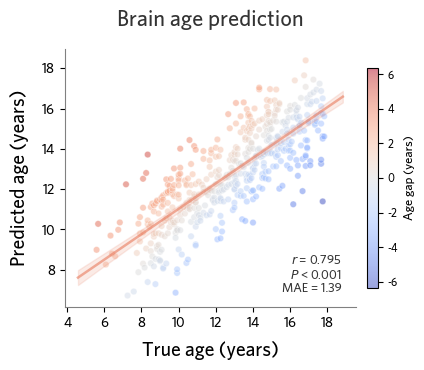

In [6]:
def plot_age_prediction_scatter(
    y_true,
    y_pred,
    r_value,
    p_value,
    mae,
    x_label='True age (years)',
    y_label='Predicted age (years)',
    title='Brain age prediction',
    line_color='#E87A5D',
    cmap='coolwarm',
    line_extend=1,
    figsize=(4.4, 3.8),
):
    """Display observed versus predicted age with residual coloring."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    residuals = y_pred - y_true

    fig, ax = plt.subplots(figsize=figsize)
    max_abs_residual = np.max(np.abs(residuals))
    norm = TwoSlopeNorm(
        vcenter=0,
        vmin=-max_abs_residual,
        vmax=max_abs_residual,
    )
    scatter = ax.scatter(
        y_true,
        y_pred,
        c=residuals,
        cmap=cmap,
        norm=norm,
        s=22,
        alpha=0.5,
        edgecolor='white',
        linewidth=0.5,
    )
    colorbar = fig.colorbar(scatter, ax=ax, pad=0.03, shrink=0.85)
    colorbar.set_label('Age gap (years)', fontsize=9)
    colorbar.ax.tick_params(labelsize=8)

    slope, intercept, _, _, _ = stats.linregress(y_true, y_pred)
    x_line = np.linspace(
        y_true.min() - line_extend,
        y_true.max() + line_extend,
        200,
    )
    y_line = slope * x_line + intercept

    n_samples = len(y_true)
    x_mean = y_true.mean()
    residual_standard_error = np.sqrt(
        np.sum((y_pred - slope * y_true - intercept) ** 2) / (n_samples - 2)
    )
    confidence_interval = (
        stats.t.ppf(0.975, n_samples - 2)
        * residual_standard_error
        * np.sqrt(
            1 / n_samples
            + (x_line - x_mean) ** 2 / np.sum((y_true - x_mean) ** 2)
        )
    )

    ax.plot(x_line, y_line, color=line_color, linewidth=1.8, alpha=0.6)
    ax.fill_between(
        x_line,
        y_line - confidence_interval,
        y_line + confidence_interval,
        color=line_color,
        alpha=0.15,
    )

    p_text = '< 0.001' if p_value < 0.001 else f'= {p_value:.3f}'
    annotation = f'$r$ = {r_value:.3f}\n$P$ {p_text}\nMAE = {mae:.2f}'
    ax.text(
        0.95,
        0.05,
        annotation,
        transform=ax.transAxes,
        ha='right',
        va='bottom',
        fontsize=9,
        color='#333333',
    )

    ax.set_title(title, fontsize=16, pad=16, color='#333333')
    ax.set_xlabel(x_label, fontsize=14, labelpad=8)
    ax.set_ylabel(y_label, fontsize=14, labelpad=9)
    ax.xaxis.set_major_locator(MultipleLocator(2))
    ax.yaxis.set_major_locator(MultipleLocator(2))
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.grid(False)

    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
    for spine in ('left', 'bottom'):
        ax.spines[spine].set_color('gray')
        ax.spines[spine].set_linewidth(0.8)

    fig.tight_layout()
    plt.show()
    return fig, ax


fig, ax = plot_age_prediction_scatter(
    y_true=y_true_all,
    y_pred=y_pred_all,
    r_value=r_value,
    p_value=p_value,
    mae=mae,
)


In [10]:
def plot_age_prediction_scatter(
    y_true,
    y_pred,
    r_value,
    p_value,
    mae,
    x_label='True age (years)',
    y_label='Predicted age (years)',
    title='Brain age prediction',
    line_color='#E87A5D',
    cmap='coolwarm',
    line_extend=1,
    figsize=(4.4, 3.8),
):
    """Display observed versus predicted age with residual coloring."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    residuals = y_pred - y_true

    fig, ax = plt.subplots(figsize=figsize)
    max_abs_residual = np.max(np.abs(residuals))
    norm = TwoSlopeNorm(
        vcenter=0,
        vmin=-max_abs_residual,
        vmax=max_abs_residual,
    )
    scatter = ax.scatter(
        y_true,
        y_pred,
        c=residuals,
        cmap=cmap,
        norm=norm,
        s=22,
        alpha=0.5,
        edgecolor='white',
        linewidth=0.5,
    )
    colorbar = fig.colorbar(scatter, ax=ax, pad=0.03, shrink=0.85)
    colorbar.set_label('Age gap (years)', fontsize=9)
    colorbar.ax.tick_params(labelsize=8)

    slope, intercept, _, _, _ = stats.linregress(y_true, y_pred)
    x_line = np.linspace(
        y_true.min() - line_extend,
        y_true.max() + line_extend,
        200,
    )
    y_line = slope * x_line + intercept

    n_samples = len(y_true)
    x_mean = y_true.mean()
    residual_standard_error = np.sqrt(
        np.sum((y_pred - slope * y_true - intercept) ** 2) / (n_samples - 2)
    )
    confidence_interval = (
        stats.t.ppf(0.975, n_samples - 2)
        * residual_standard_error
        * np.sqrt(
            1 / n_samples
            + (x_line - x_mean) ** 2 / np.sum((y_true - x_mean) ** 2)
        )
    )

    ax.plot(x_line, y_line, color=line_color, linewidth=1.8, alpha=0.6)
    ax.fill_between(
        x_line,
        y_line - confidence_interval,
        y_line + confidence_interval,
        color=line_color,
        alpha=0.15,
    )

    p_text = '< 0.001' if p_value < 0.001 else f'= {p_value:.3f}'
    annotation = f'$r$ = {r_value:.3f}\n$P$ {p_text}\nMAE = {mae:.2f}'
    ax.text(
        0.95,
        0.05,
        annotation,
        transform=ax.transAxes,
        ha='right',
        va='bottom',
        fontsize=9,
        color='#333333',
    )

    ax.set_title(title, fontsize=16, pad=16, color='#333333')
    ax.set_xlabel(x_label, fontsize=14, labelpad=8)
    ax.set_ylabel(y_label, fontsize=14, labelpad=9)
    ax.xaxis.set_major_locator(MultipleLocator(2))
    ax.yaxis.set_major_locator(MultipleLocator(2))
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.grid(False)

    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
    for spine in ('left', 'bottom'):
        ax.spines[spine].set_color('gray')
        ax.spines[spine].set_linewidth(0.8)

    fig.tight_layout()
    plt.show()
    return fig, ax


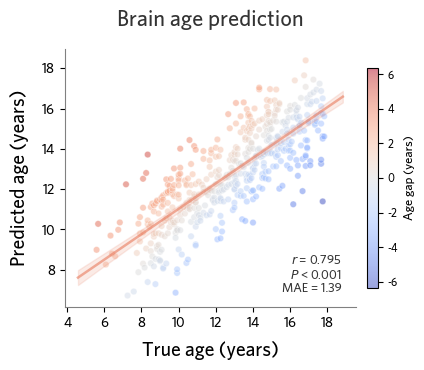

In [9]:

fig, ax = plot_age_prediction_scatter(
    y_true=y_true_all,
    y_pred=y_pred_all,
    r_value=r_value,
    p_value=p_value,
    mae=mae,
)